In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [58]:
print("Статистика по датасету:")
display(df.describe())

Статистика по датасету:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


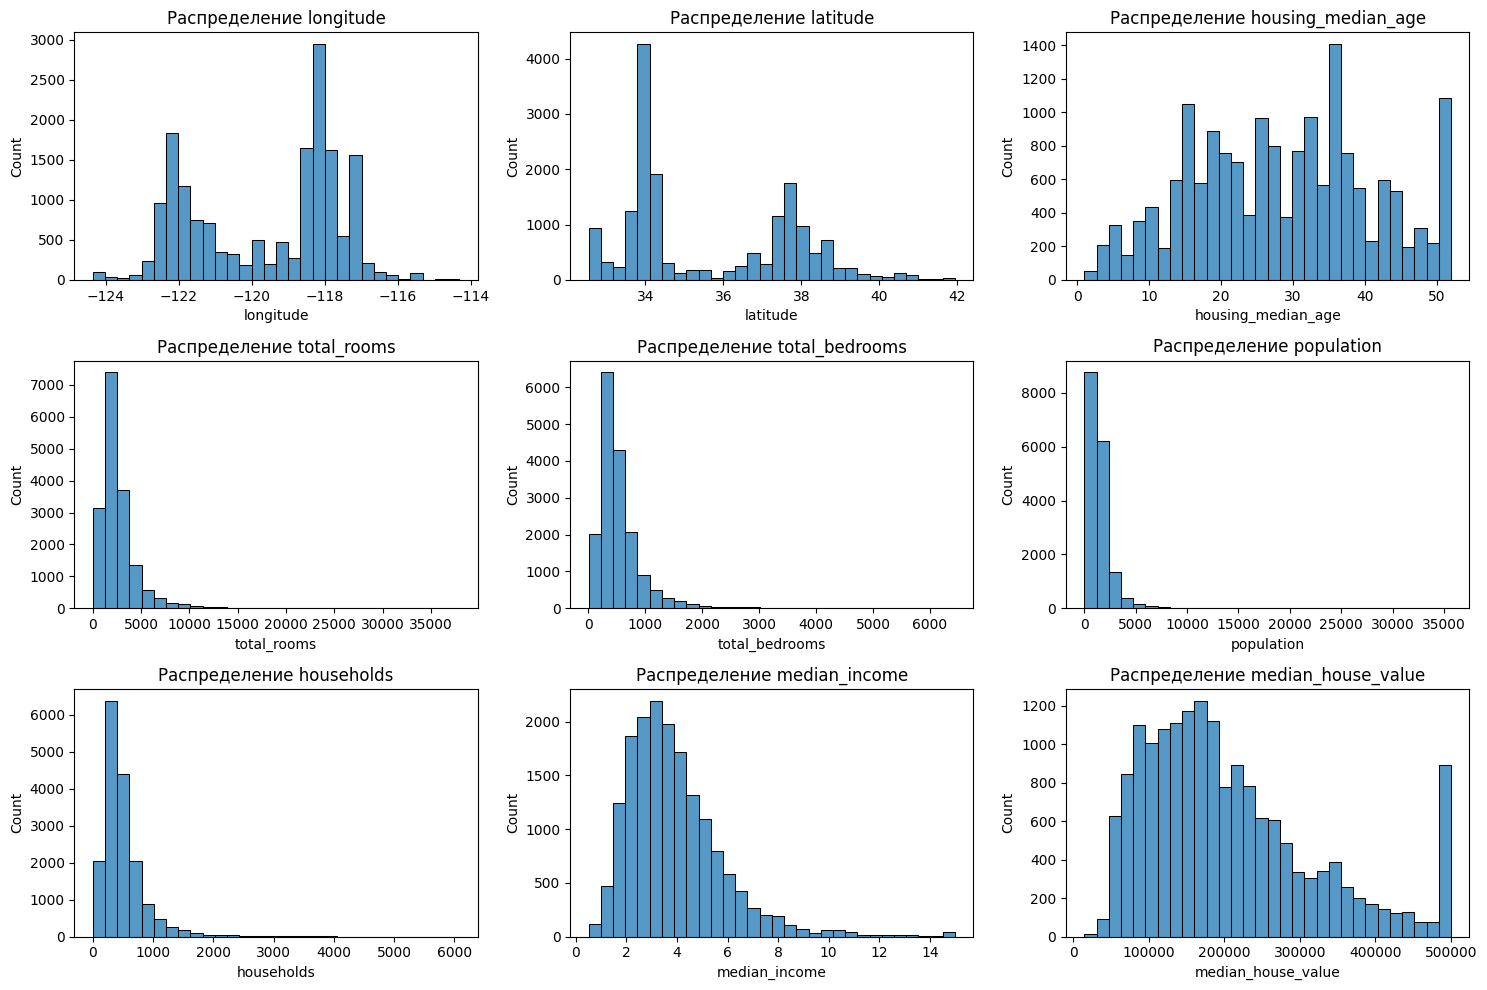

In [59]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

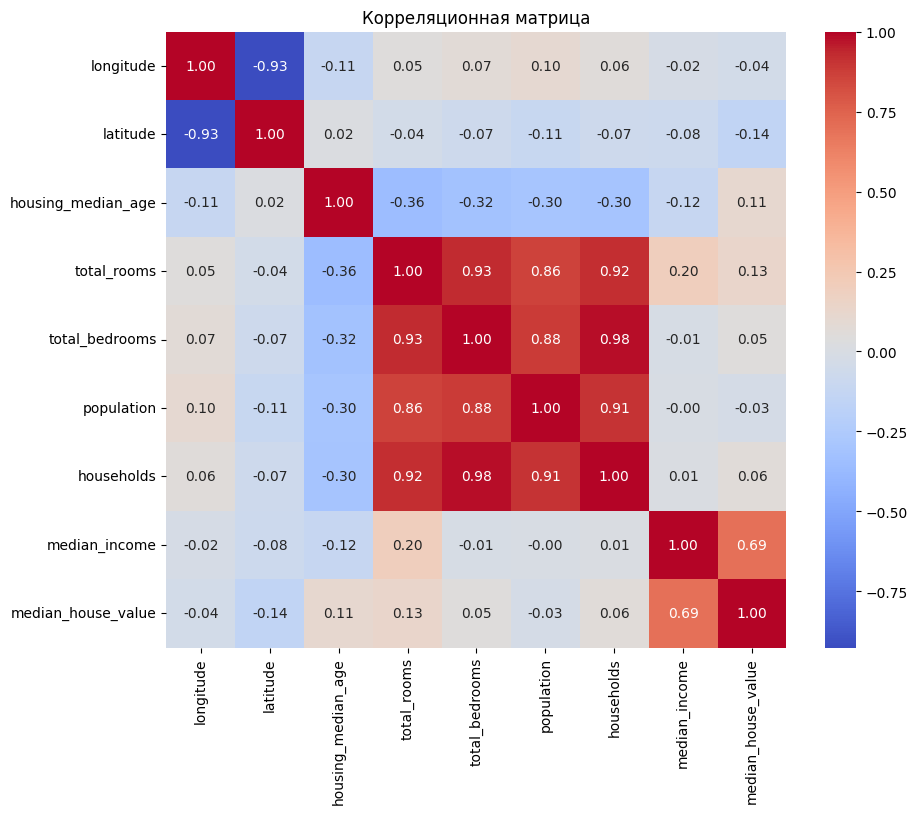

In [60]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

In [61]:
df = df.fillna(df.median())

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

target_col = 'median_house_value'
features = df.columns.drop(target_col)

df_normalized = df.copy()
for col in features:
    mean = df[col].mean()
    std = df[col].std()
    df_normalized[col] = (df[col] - mean) / std

In [62]:
def train_test_split_custom(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    test_size_int = int(len(X) * test_size)

    test_idx = indices[:test_size_int]
    train_idx = indices[test_size_int:]

    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

X_full = df_normalized[features]
y_full = df_normalized[target_col]

X_train, X_test, y_train, y_test = train_test_split_custom(X_full, y_full)

print(f"Размер обучающей выборки (Train): {X_train.shape[0]} строк")
print(f"Размер тестовой выборки (Test):   {X_test.shape[0]} строк")

Размер обучающей выборки (Train): 13600 строк
Размер тестовой выборки (Test):   3400 строк


In [63]:
class CustomLinearRegression:
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.weights = None # B = [a, b1, b2, ... bp]'

    def fit(self, X, y):
        X_mat = np.c_[np.ones((X.shape[0], 1)), X[self.feature_names].values]
        y_vec = y.values.reshape(-1, 1)

        X_T = X_mat.T # B = (X'X)^-1 * X'Y
        self.weights = np.linalg.pinv(X_T @ X_mat) @ X_T @ y_vec

    def predict(self, X):
        X_mat = np.c_[np.ones((X.shape[0], 1)), X[self.feature_names].values]
        return (X_mat @ self.weights).flatten()

    def print_equation(self):
        a = self.weights[0][0]
        coeffs = self.weights[1:].flatten()

        eq = f"y_hat = {a:.4f}"
        for name, b in zip(self.feature_names, coeffs):
            sign = "+" if b >= 0 else "-"
            eq += f" {sign} {abs(b):.4f}*{name}"
        print("Регрессионная модель в скалярном виде:")
        print(eq)

def r2_score_custom(y_true, y_pred):
    ss_res = np.sum((y_true.values - y_pred) ** 2)
    ss_tot = np.sum((y_true.values - np.mean(y_true.values)) ** 2)
    return 1 - (ss_res / ss_tot)

def rss_score_custom(y_true, y_pred):
    """Сумма квадратов остатков (Q = e'e)"""
    return np.sum((y_true.values - y_pred) ** 2)

In [64]:
features_1 = ['median_income', 'housing_median_age', 'longitude', 'latitude']

model_1 = CustomLinearRegression(features_1)
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

r2_1 = r2_score_custom(y_test, y_pred_1)
rss_1 = rss_score_custom(y_test, y_pred_1)

print("--- РЕЗУЛЬТАТЫ МОДЕЛИ 1 ---")
print(f"Признаки: {features_1}")
model_1.print_equation()
print("\nОценки параметров (Вектор B):")
print(f"Свободный член (a): {model_1.weights[0][0]:.4f}")
for name, w in zip(features_1, model_1.weights[1:].flatten()):
    print(f"Коэффициент при {name}: {w:.4f}")

print("-" * 30)
print(f"Коэффициент детерминации (R^2): {r2_1:.5f}")
print(f"Сумма квадратов ошибок (RSS):   {rss_1:.2f}")
print("Первые 5 предсказаний:          ", np.round(y_pred_1[:5], 2))
print("Первые 5 реальных значений:     ", np.round(y_test.values[:5], 2))

--- РЕЗУЛЬТАТЫ МОДЕЛИ 1 ---
Признаки: ['median_income', 'housing_median_age', 'longitude', 'latitude']
Регрессионная модель в скалярном виде:
y_hat = 206887.9873 + 71769.9021*median_income + 11648.4522*housing_median_age - 91730.6008*longitude - 96005.0921*latitude

Оценки параметров (Вектор B):
Свободный член (a): 206887.9873
Коэффициент при median_income: 71769.9021
Коэффициент при housing_median_age: 11648.4522
Коэффициент при longitude: -91730.6008
Коэффициент при latitude: -96005.0921
------------------------------
Коэффициент детерминации (R^2): 0.61379
Сумма квадратов ошибок (RSS):   18093052723736.47
Первые 5 предсказаний:           [141432.23 390611.83 105746.97 175976.12 154909.47]
Первые 5 реальных значений:      [142700. 500001.  61800. 162800.  90600.]


In [65]:
features_2 = ['median_income', 'housing_median_age', 'longitude', 'latitude',
              'total_rooms', 'total_bedrooms', 'population', 'households']

model_2 = CustomLinearRegression(features_2)
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

r2_2 = r2_score_custom(y_test, y_pred_2)
rss_2 = rss_score_custom(y_test, y_pred_2)

print("--- РЕЗУЛЬТАТЫ МОДЕЛИ 2 ---")
print(f"Признаки: {features_2}")
model_2.print_equation()
print("\nОценки параметров (Вектор B):")
print(f"Свободный член (a): {model_2.weights[0][0]:.4f}")
for name, w in zip(features_2, model_2.weights[1:].flatten()):
    print(f"Коэффициент при {name}: {w:.4f}")

print("-" * 30)
print(f"Коэффициент детерминации (R^2): {r2_2:.5f}")
print(f"Сумма квадратов ошибок (RSS):   {rss_2:.2f}")
print("Первые 5 предсказаний:          ", np.round(y_pred_2[:5], 2))
print("Первые 5 реальных значений:     ", np.round(y_test.values[:5], 2))

--- РЕЗУЛЬТАТЫ МОДЕЛИ 2 ---
Признаки: ['median_income', 'housing_median_age', 'longitude', 'latitude', 'total_rooms', 'total_bedrooms', 'population', 'households']
Регрессионная модель в скалярном виде:
y_hat = 206937.5738 + 76697.8291*median_income + 14244.9435*housing_median_age - 87155.0546*longitude - 92132.8199*latitude - 19277.8401*total_rooms + 47927.8484*total_bedrooms - 40929.0812*population + 17360.1758*households

Оценки параметров (Вектор B):
Свободный член (a): 206937.5738
Коэффициент при median_income: 76697.8291
Коэффициент при housing_median_age: 14244.9435
Коэффициент при longitude: -87155.0546
Коэффициент при latitude: -92132.8199
Коэффициент при total_rooms: -19277.8401
Коэффициент при total_bedrooms: 47927.8484
Коэффициент при population: -40929.0812
Коэффициент при households: 17360.1758
------------------------------
Коэффициент детерминации (R^2): 0.66364
Сумма квадратов ошибок (RSS):   15757838581159.41
Первые 5 предсказаний:           [143770.4  398615.57  8634

In [66]:
features_3 = ['median_income', 'housing_median_age', 'longitude', 'latitude',
              'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

model_3 = CustomLinearRegression(features_3)
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)

r2_3 = r2_score_custom(y_test, y_pred_3)
rss_3 = rss_score_custom(y_test, y_pred_3)

print("--- РЕЗУЛЬТАТЫ МОДЕЛИ 3 (С СИНТЕТИЧЕСКИМИ ПРИЗНАКАМИ) ---")
print(f"Признаки: {features_3}")
model_3.print_equation()
print("\nОценки параметров (Вектор B):")
print(f"Свободный член (a): {model_3.weights[0][0]:.4f}")
for name, w in zip(features_3, model_3.weights[1:].flatten()):
    print(f"Коэффициент при {name}: {w:.4f}")

print("-" * 30)
print(f"Коэффициент детерминации (R^2): {r2_3:.5f}")
print(f"Сумма квадратов ошибок (RSS):   {rss_3:.2f}")
print("Первые 5 предсказаний:          ", np.round(y_pred_3[:5], 2))
print("Первые 5 реальных значений:     ", np.round(y_test.values[:5], 2))

--- РЕЗУЛЬТАТЫ МОДЕЛИ 3 (С СИНТЕТИЧЕСКИМИ ПРИЗНАКАМИ) ---
Признаки: ['median_income', 'housing_median_age', 'longitude', 'latitude', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Регрессионная модель в скалярном виде:
y_hat = 206818.8449 + 83240.1635*median_income + 11682.1410*housing_median_age - 86984.6326*longitude - 89268.4152*latitude + 7925.4107*rooms_per_household + 21662.7618*bedrooms_per_room - 3500.0932*population_per_household

Оценки параметров (Вектор B):
Свободный член (a): 206818.8449
Коэффициент при median_income: 83240.1635
Коэффициент при housing_median_age: 11682.1410
Коэффициент при longitude: -86984.6326
Коэффициент при latitude: -89268.4152
Коэффициент при rooms_per_household: 7925.4107
Коэффициент при bedrooms_per_room: 21662.7618
Коэффициент при population_per_household: -3500.0932
------------------------------
Коэффициент детерминации (R^2): 0.63185
Сумма квадратов ошибок (RSS):   17246961533254.93
Первые 5 предсказаний:           [13

,Модель,Кол-во признаков,R^2 (Коэфф. детерминации),RSS (Сумма квадр. остатков)
0,Модель 1 (Базовая),4,0.613793,1.809305e+13
1,Модель 2 (Все сырые),8,0.663640,1.575784e+13
2,Модель 3 (Синтетические),7,0.631853,1.724696e+13


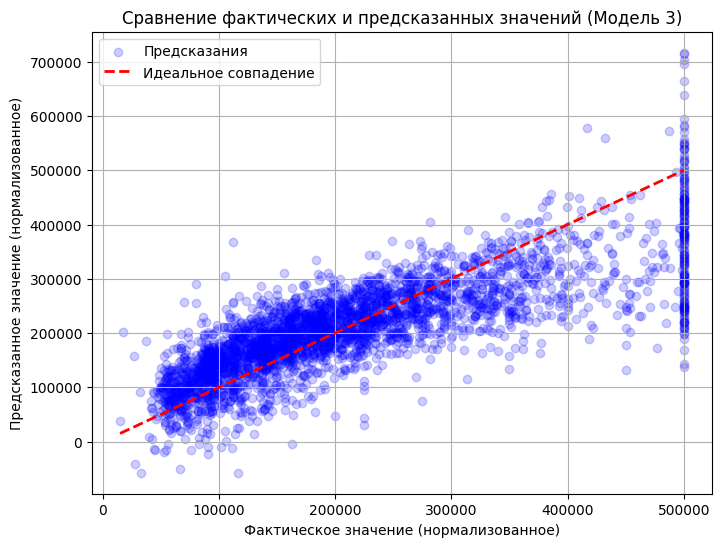

In [67]:
summary_df = pd.DataFrame({
    'Модель': ['Модель 1 (Базовая)', 'Модель 2 (Все сырые)', 'Модель 3 (Синтетические)'],
    'Кол-во признаков': [len(features_1), len(features_2), len(features_3)],
    'R^2 (Коэфф. детерминации)': [r2_1, r2_2, r2_3],
    'RSS (Сумма квадр. остатков)': [rss_1, rss_2, rss_3]
})

display(summary_df)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_3, alpha=0.2, color='blue', label='Предсказания')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное совпадение')
plt.title('Сравнение фактических и предсказанных значений (Модель 3)')
plt.xlabel('Фактическое значение (нормализованное)')
plt.ylabel('Предсказанное значение (нормализованное)')
plt.legend()
plt.grid(True)
plt.show()